In [1]:
import mplhep as hep
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np
import os
import glob

In [2]:
from ntupelizer.aleph.tools import io

In [3]:
INPUT_DIR = "/local/laurits/ALEPH/ALEPH/"
OUTPUT_DIR = "/home/laurits/ALEPH_data_overview"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
data_wcp = os.path.join(INPUT_DIR, "*.parquet")
size_in_bytes = sum([os.path.getsize(path) for path in glob.glob(data_wcp)])
size_in_megabytes = size_in_bytes / (1024 * 1024)

print(f"Dataset size: {size_in_megabytes:.2f} MB")



Dataset size: 6529.97 MB


In [5]:
all_data = io.load_all_data(INPUT_DIR)

100%|███████████████████████████████████████████████████████████████████████████████| 189/189 [05:47<00:00,  1.84s/it]


Input data loaded


In [34]:
all_data.fields



['part_ptrel',
 'part_erel',
 'part_signed_deta',
 'part_signed_dphi',
 'part_deltaR',
 'part_deta',
 'part_dphi',
 'jet_mass_from_p4s',
 'jet_pt_from_p4s',
 'jet_eta_from_p4s',
 'jet_phi_from_p4s',
 'jet_nparticles',
 'jet_pt',
 'jet_eta',
 'jet_phi',
 'jet_energy',
 'jet_mass',
 'jet_sdmass',
 'jet_tau1',
 'jet_tau2',
 'jet_tau3',
 'jet_tau4',
 'part_px',
 'part_py',
 'part_pz',
 'part_energy',
 'part_pt',
 'part_eta',
 'part_phi',
 'part_mass',
 'part_d0val',
 'part_d0err',
 'part_dzval',
 'part_dzerr',
 'part_charge',
 'part_isChargedHadron',
 'part_isNeutralHadron',
 'part_isPhoton',
 'part_isElectron',
 'part_isMuon']

In [6]:
num_jets = len(all_data.jet_energy)
print(f"There are == {num_jets:,} jets == in the dataset".replace(",", " "))

There are == 10 286 107 jets == in the dataset


# General

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mplhep as hep

plt.style.use(hep.style.CMS)


def plot_2d_heatmap(
    x_data, y_data,
    xlabel="Number of jet constituents",
    ylabel=r"Candidate $p_T$ [GeV]",
    title="",
    x_bins=None,
    y_bins=50,
    y_log=True,
    log_colorbar=True,
    fig=None, ax=None,
    norm=None,
):
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    # Integer bins for jet constituents
    if x_bins is None:
        x_bins = np.arange(int(np.min(x_data)) - 0.5, int(np.max(x_data)) + 1.5, 1)

    # Log-spaced bins for pT
    if y_log:
        positive_y = y_data[y_data > 0]
        y_bins = np.logspace(np.log10(np.min(positive_y)), np.log10(np.max(positive_y)), y_bins + 1)

    if norm is None and log_colorbar:
        norm = mcolors.LogNorm()

    h, xedges, yedges, im = ax.hist2d(
        x_data, y_data, bins=[x_bins, y_bins], norm=norm, cmap="viridis", cmin=1,
    )

    if y_log:
        ax.set_yscale("log")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    return fig, ax, im

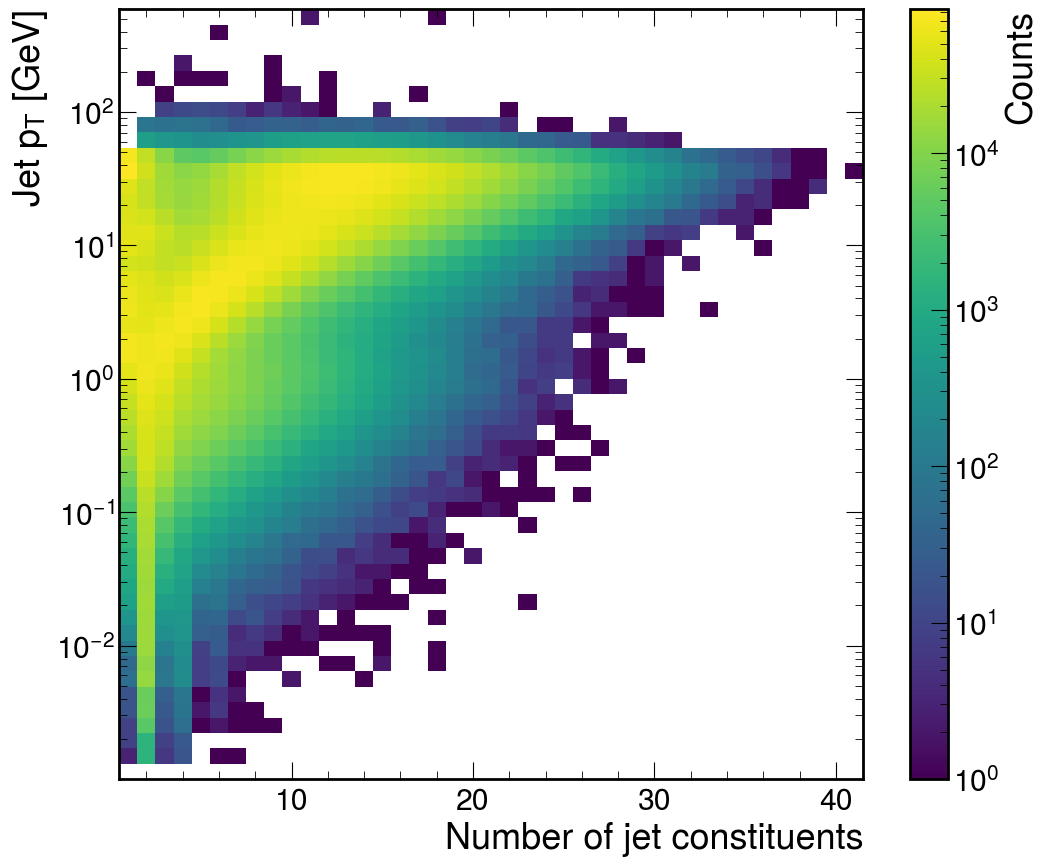

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))
norm = mcolors.LogNorm()
_, _, im = plot_2d_heatmap(ak.num(all_data.part_charge, axis=1), all_data.jet_pt, title="", fig=fig, ax=ax, norm=norm, ylabel=r"Jet $p_T$ [GeV]")
fig.colorbar(im, ax=ax, label="Counts")
output_path = os.path.join(OUTPUT_DIR, "jetPt_v_nConst.png")
fig.savefig(output_path)
# plt.close("all")

# Jet kinematics

In [9]:
def plot_distribution(
    data,
    title,
    color="k",
    xlabel="Variable",
    ylabel="Events",
    xscale="log",
    yscale="log",
    n_bins=50,
    hist_range=None,
    fig=None,
    ax=None,
    label="",
    bins=None
):
    if (fig is None) or (ax is None):
        fig, ax = plt.subplots()
    fig.subplots_adjust(hspace=0.05)
    data = np.array(data)
    if xscale == "log":
        data = data[data > 0]

    hist_range = (np.min(data), np.max(data))
    if bins is None:
        if xscale == "log":
            bins = np.logspace(np.log10(hist_range[0]), np.log10(hist_range[1]), n_bins + 1)
        else:
            bins = np.linspace(hist_range[0], hist_range[1], n_bins + 1)
    h, _ = np.histogram(data, bins=bins)
    # bin_centers = np.sqrt(bins[:-1] * bins[1:])

    hep.histplot(h, bins=bins, color=color, ax=ax, label=label)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.set_yscale(yscale)
    ax.set_xscale(xscale)
    ax.set_title(title)

    return fig, ax, bins

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


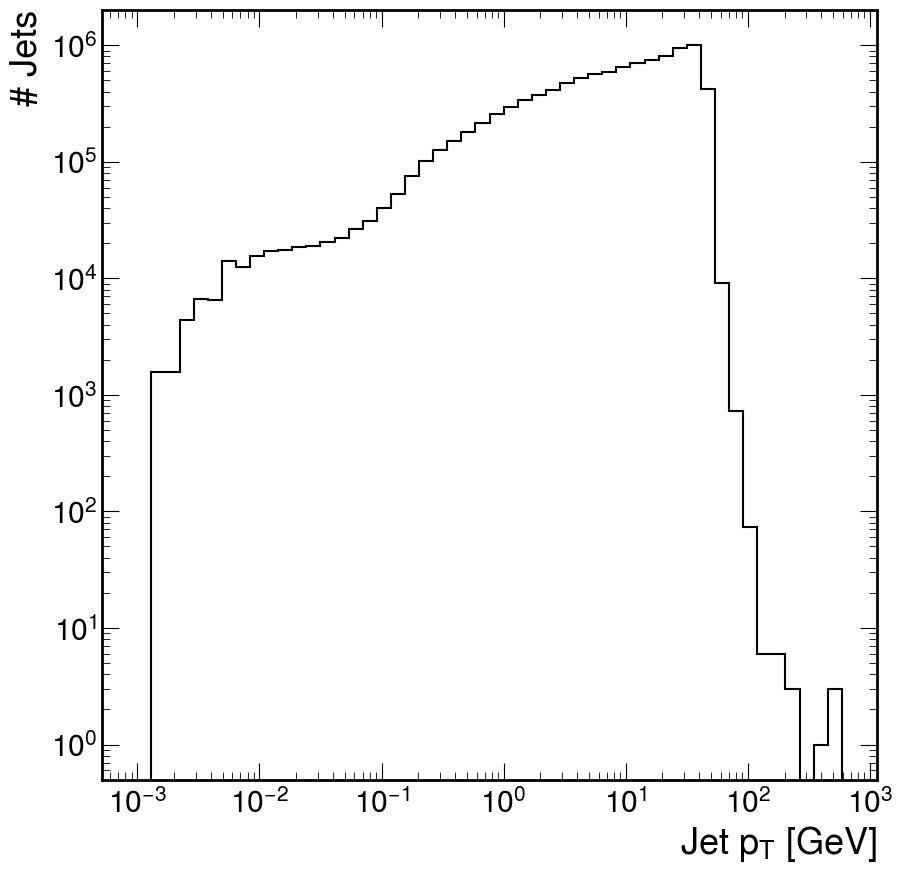

In [10]:
fig, ax, _ = plot_distribution(all_data.jet_pt, title="", xlabel=r"Jet $p_T$ [GeV]", ylabel="# Jets")
output_path = os.path.join(OUTPUT_DIR, "jet_pt.png")
fig.savefig(output_path)

In [11]:
fig, ax, _ = plot_distribution(all_data.jet_phi, title="", xlabel=r"Jet $\phi$ [deg]", ylabel="# Jets", xscale="linear")
output_path = os.path.join(OUTPUT_DIR, "jet_phi.png")
fig.savefig(output_path)
plt.close("all")

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


In [12]:
fig, ax, _ = plot_distribution(all_data.jet_eta, title="", xlabel=r"Jet $\eta$", ylabel="# Jets", xscale="linear")
output_path = os.path.join(OUTPUT_DIR, "jet_eta.png")
fig.savefig(output_path)
plt.close("all")

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


In [13]:
fig, ax, _ = plot_distribution(all_data.jet_energy, title="", xlabel=r"Jet mass [GeV]", ylabel="# Jets", xscale="linear")
output_path = os.path.join(OUTPUT_DIR, "jet_mass.png")
fig.savefig(output_path)
plt.close("all")


/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


In [14]:
fig, ax, _ = plot_distribution(ak.num(all_data.part_charge, axis=1), title="", xlabel=r"# jet constituents", ylabel="# Jets", xscale="linear")
output_path = os.path.join(OUTPUT_DIR, "jet_nparticles.png")
fig.savefig(output_path)
plt.close("all")

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


# Jet constituent kinematics

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.

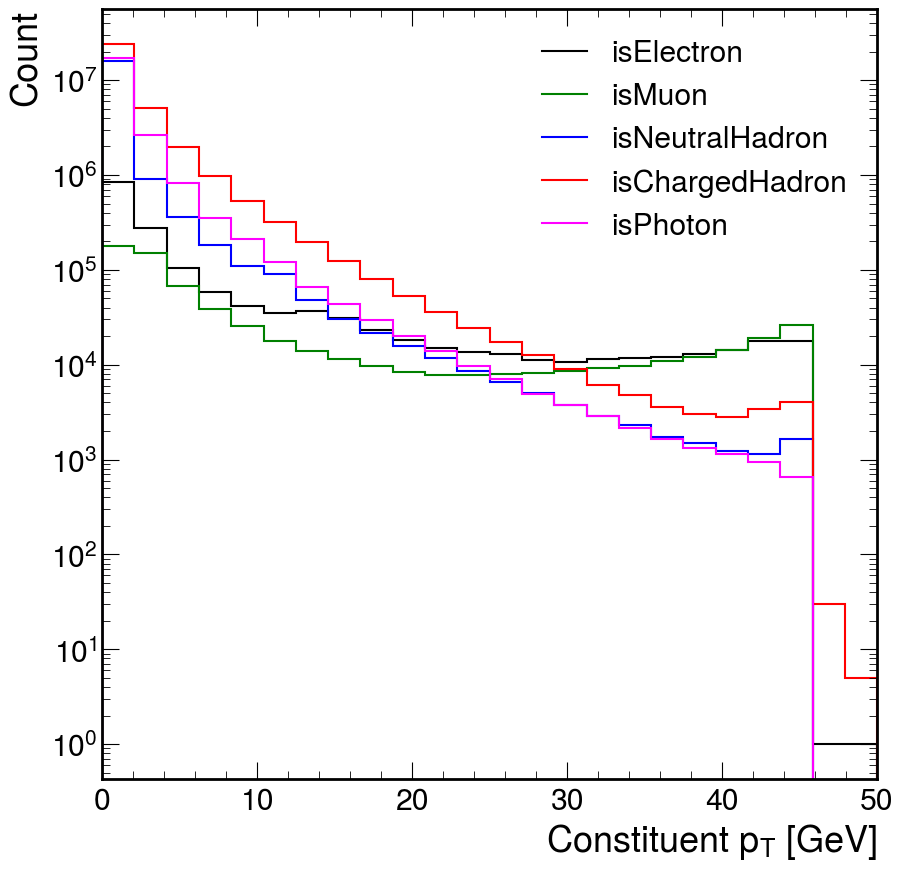

In [15]:
field_data = all_data.part_pt
flat_data = ak.flatten(field_data)

electron_data = flat_data[ak.flatten(all_data.part_isElectron) == 1]
muon_data = flat_data[ak.flatten(all_data.part_isMuon) == 1]
neutralHadron_data = flat_data[ak.flatten(all_data.part_isNeutralHadron) == 1]
chargedHadron_data = flat_data[ak.flatten(all_data.part_isChargedHadron) == 1]
photon_data = flat_data[ak.flatten(all_data.part_isPhoton) == 1]

bins = np.linspace(0, 50, 25)
fig, ax, _ = plot_distribution(electron_data, title="", xlabel=r"Constituent $p_T$ [GeV]", ylabel="Count", xscale="linear", label="isElectron", color="k", bins=bins)
fig, ax, _ = plot_distribution(muon_data, title="", xlabel=r"Constituent $p_T$ [GeV]", ylabel="Count", xscale="linear", label="isMuon", color="g", fig=fig, ax=ax, bins=bins)
fig, ax, _ = plot_distribution(neutralHadron_data, title="", xlabel=r"Constituent $p_T$ [GeV]", ylabel="Count", xscale="linear", label="isNeutralHadron", color="b", fig=fig, ax=ax, bins=bins)
fig, ax, _ = plot_distribution(chargedHadron_data, title="", xlabel=r"Constituent $p_T$ [GeV]", ylabel="Count", xscale="linear", label="isChargedHadron", color="r", fig=fig, ax=ax, bins=bins)
fig, ax, _ = plot_distribution(photon_data, title="", xlabel=r"Constituent $p_T$ [GeV]", ylabel="Count", xscale="linear", label="isPhoton", color="magenta", fig=fig, ax=ax, bins=bins)
ax.set_xlim((0, 50))
output_path = os.path.join(OUTPUT_DIR, "part_pt.png")
ax.legend()
fig.savefig(output_path)
# plt.close("all")

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.

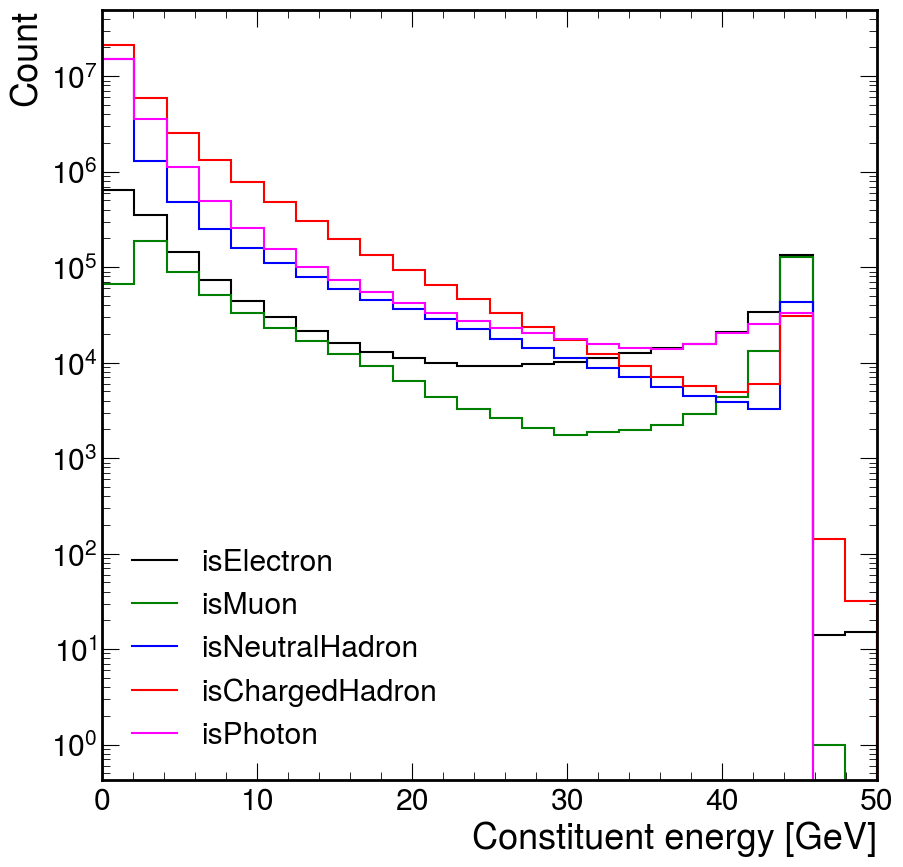

In [16]:
field_data = all_data.part_energy
flat_data = ak.flatten(field_data)

electron_data = flat_data[ak.flatten(all_data.part_isElectron) == 1]
muon_data = flat_data[ak.flatten(all_data.part_isMuon) == 1]
neutralHadron_data = flat_data[ak.flatten(all_data.part_isNeutralHadron) == 1]
chargedHadron_data = flat_data[ak.flatten(all_data.part_isChargedHadron) == 1]
photon_data = flat_data[ak.flatten(all_data.part_isPhoton) == 1]

bins = np.linspace(0, 50, 25)

fig, ax, _ = plot_distribution(electron_data, title="", xlabel=r"Constituent energy [GeV]", ylabel="Count", xscale="linear", label="isElectron", color="k", bins=bins)
fig, ax, _ = plot_distribution(muon_data, title="", xlabel=r"Constituent energy [GeV]", ylabel="Count", xscale="linear", label="isMuon", color="g", fig=fig, ax=ax, bins=bins)
fig, ax, _ = plot_distribution(neutralHadron_data, title="", xlabel=r"Constituent energy [GeV]", ylabel="Count", xscale="linear", label="isNeutralHadron", color="b", fig=fig, ax=ax, bins=bins)
fig, ax, _ = plot_distribution(chargedHadron_data, title="", xlabel=r"Constituent energy [GeV]", ylabel="Count", xscale="linear", label="isChargedHadron", color="r", fig=fig, ax=ax, bins=bins)
fig, ax, _ = plot_distribution(photon_data, title="", xlabel=r"Constituent energy [GeV]", ylabel="Count", xscale="linear", label="isPhoton", color="magenta", fig=fig, ax=ax, bins=bins)
ax.set_xlim((0, 50))
output_path = os.path.join(OUTPUT_DIR, "part_energy.png")
ax.legend()
fig.savefig(output_path)
# plt.close("all")

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.

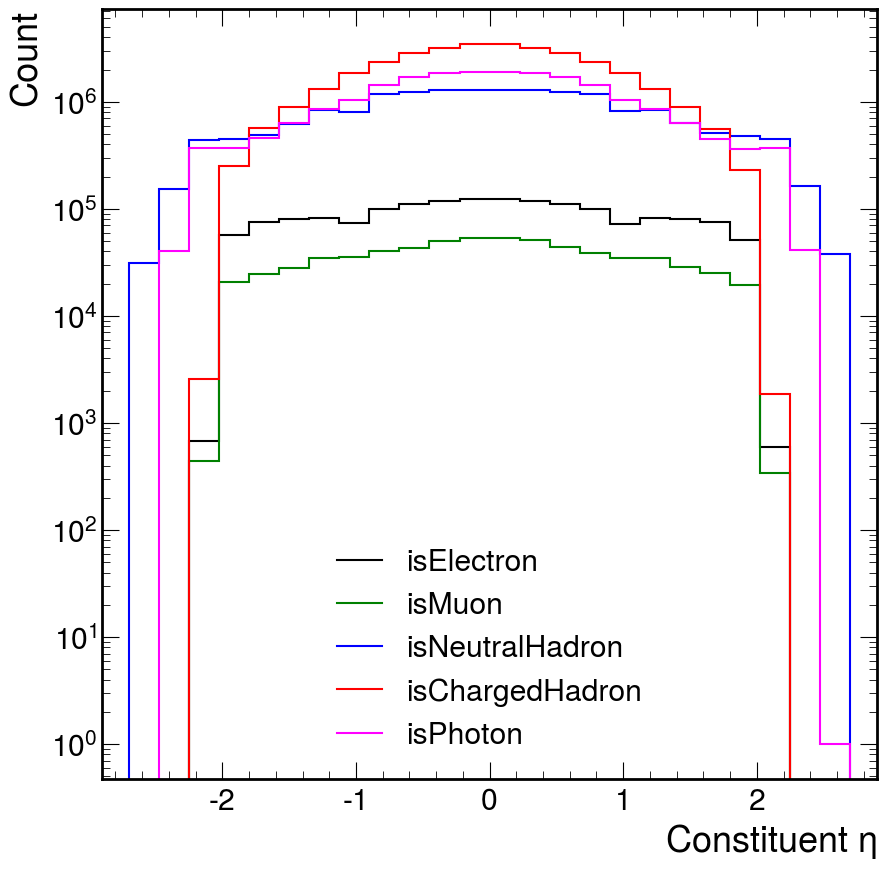

In [17]:
field_data = all_data.part_eta
flat_data = ak.flatten(field_data)

electron_data = flat_data[ak.flatten(all_data.part_isElectron) == 1]
muon_data = flat_data[ak.flatten(all_data.part_isMuon) == 1]
neutralHadron_data = flat_data[ak.flatten(all_data.part_isNeutralHadron) == 1]
chargedHadron_data = flat_data[ak.flatten(all_data.part_isChargedHadron) == 1]
photon_data = flat_data[ak.flatten(all_data.part_isPhoton) == 1]

bins = np.linspace(-2.7, 2.7, 25)
fig, ax, _ = plot_distribution(electron_data, title="", xlabel=r"Constituent $\eta$", ylabel="Count", xscale="linear", label="isElectron", color="k", bins=bins)
fig, ax, _ = plot_distribution(muon_data, title="", xlabel=r"Constituent $\eta$", ylabel="Count", xscale="linear", label="isMuon", color="g", fig=fig, ax=ax, bins=bins)
fig, ax, _ = plot_distribution(neutralHadron_data, title="", xlabel=r"Constituent $\eta$", ylabel="Count", xscale="linear", label="isNeutralHadron", color="b", fig=fig, ax=ax, bins=bins)
fig, ax, _ = plot_distribution(chargedHadron_data, title="", xlabel=r"Constituent $\eta$", ylabel="Count", xscale="linear", label="isChargedHadron", color="r", fig=fig, ax=ax, bins=bins)
fig, ax, _ = plot_distribution(photon_data, title="", xlabel=r"Constituent $\eta$", ylabel="Count", xscale="linear", label="isPhoton", color="magenta", fig=fig, ax=ax, bins=bins)
ax.set_xlim((-2.9, 2.9))
output_path = os.path.join(OUTPUT_DIR, "part_eta.png")
ax.legend()
fig.savefig(output_path)
# plt.close("all")

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.

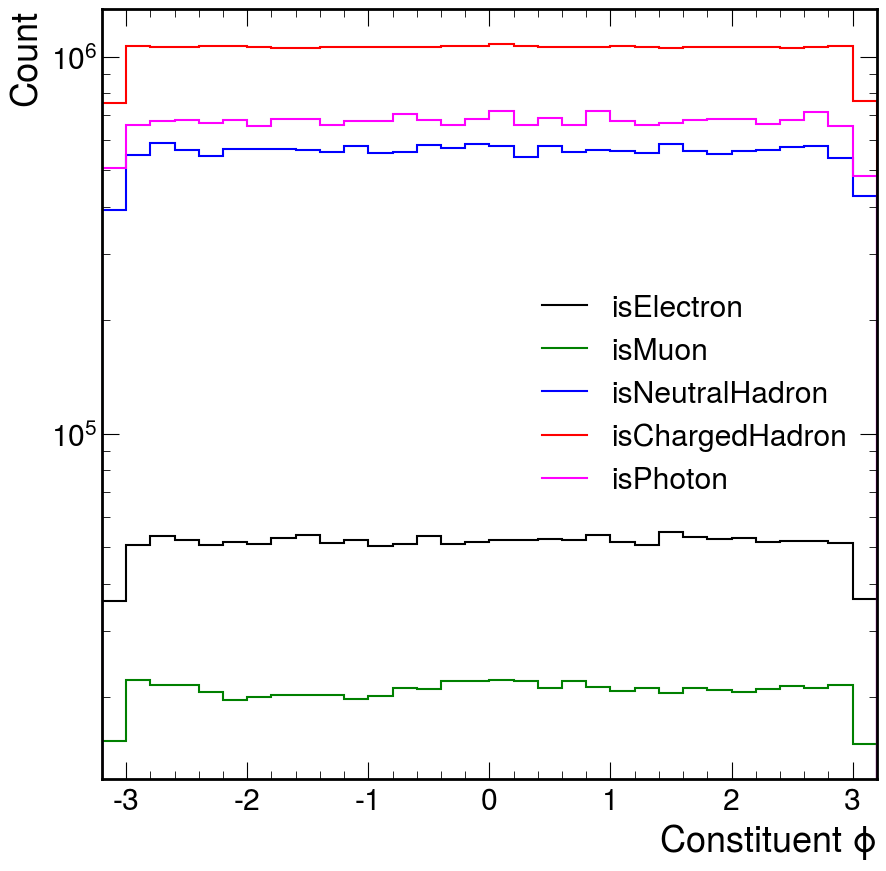

In [18]:
field_data = all_data.part_phi
flat_data = ak.flatten(field_data)

electron_data = flat_data[ak.flatten(all_data.part_isElectron) == 1]
muon_data = flat_data[ak.flatten(all_data.part_isMuon) == 1]
neutralHadron_data = flat_data[ak.flatten(all_data.part_isNeutralHadron) == 1]
chargedHadron_data = flat_data[ak.flatten(all_data.part_isChargedHadron) == 1]
photon_data = flat_data[ak.flatten(all_data.part_isPhoton) == 1]

bins = np.linspace(-3.2, 3.2, 33)
fig, ax, _ = plot_distribution(electron_data, title="", xlabel=r"Constituent $\phi$", ylabel="Count", xscale="linear", label="isElectron", color="k", bins=bins)
fig, ax, _ = plot_distribution(muon_data, title="", xlabel=r"Constituent $\phi$", ylabel="Count", xscale="linear", label="isMuon", color="g", fig=fig, ax=ax, bins=bins)
fig, ax, _ = plot_distribution(neutralHadron_data, title="", xlabel=r"Constituent $\phi$", ylabel="Count", xscale="linear", label="isNeutralHadron", color="b", fig=fig, ax=ax, bins=bins)
fig, ax, _ = plot_distribution(chargedHadron_data, title="", xlabel=r"Constituent $\phi$", ylabel="Count", xscale="linear", label="isChargedHadron", color="r", fig=fig, ax=ax, bins=bins)
fig, ax, _ = plot_distribution(photon_data, title="", xlabel=r"Constituent $\phi$", ylabel="Count", xscale="linear", label="isPhoton", color="magenta", fig=fig, ax=ax, bins=bins)
ax.set_xlim((-3.2, 3.2))
output_path = os.path.join(OUTPUT_DIR, "part_phi.png")
ax.legend()
fig.savefig(output_path)
# plt.close("all")


# Jet composition

In [19]:
n_constituents_per_jet = ak.num(all_data.part_charge, axis=1)

n_charged_constituents = ak.sum(abs(all_data.part_charge) == 1, axis=1)
n_chargedHadron_constituents = ak.sum((all_data.part_isChargedHadron == 1), axis=1)
n_electron_constituents = ak.sum((all_data.part_isElectron == 1), axis=1)
n_muon_constituents = ak.sum((all_data.part_isMuon == 1), axis=1)


n_neutral_constituents = ak.sum(abs(all_data.part_charge) == 0, axis=1)
n_neutralHadron_constituents = ak.sum((all_data.part_isNeutralHadron == 1), axis=1)
n_photon_constituents = ak.sum((all_data.part_isPhoton == 1), axis=1)



In [20]:
frac_charged_constituents = n_charged_constituents / n_constituents_per_jet
frac_chargedHadron_constituents = n_chargedHadron_constituents / n_constituents_per_jet
frac_electron_constituents = n_electron_constituents / n_constituents_per_jet
frac_muon_constituents = n_muon_constituents / n_constituents_per_jet


frac_neutral_constituents = n_neutral_constituents / n_constituents_per_jet
frac_neutralHadron_constituents = n_neutralHadron_constituents / n_constituents_per_jet
frac_photon_constituents = n_photon_constituents / n_constituents_per_jet


In [21]:
leading_particle_relpt = ak.max(all_data.part_ptrel, axis=1)

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


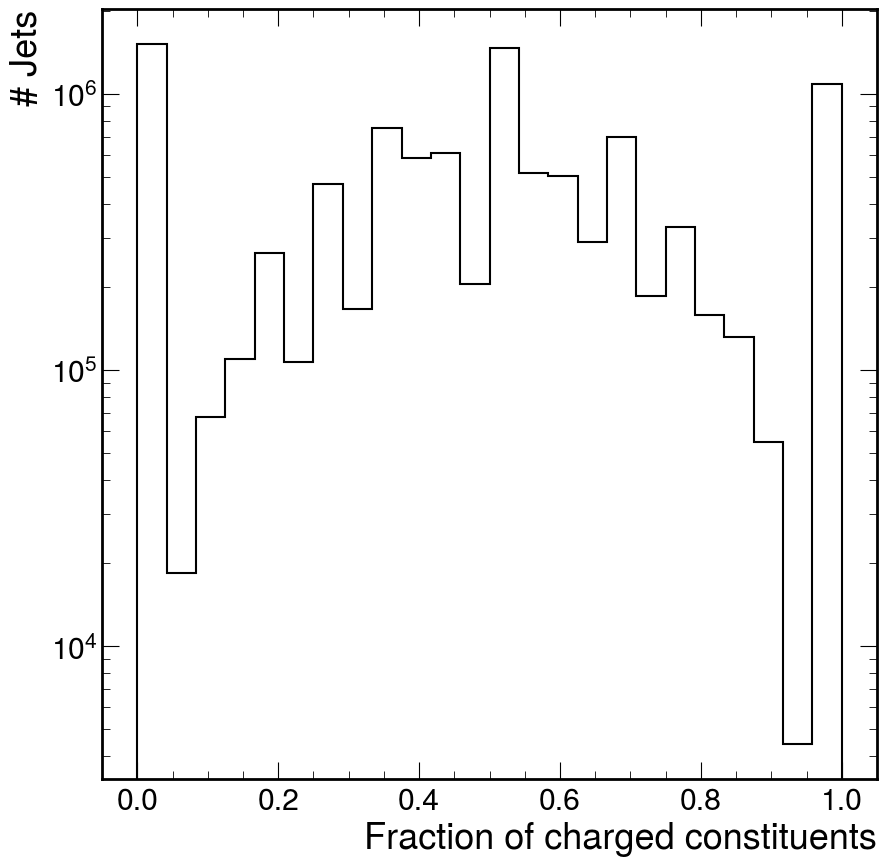

In [22]:
bins = np.linspace(0, 1, 25)
fig, ax, _ = plot_distribution(frac_charged_constituents, title="", xlabel="Fraction of charged constituents", ylabel="# Jets", xscale="linear", bins=bins)
output_path = os.path.join(OUTPUT_DIR, "frac_charged_constituents.png")
fig.savefig(output_path)

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


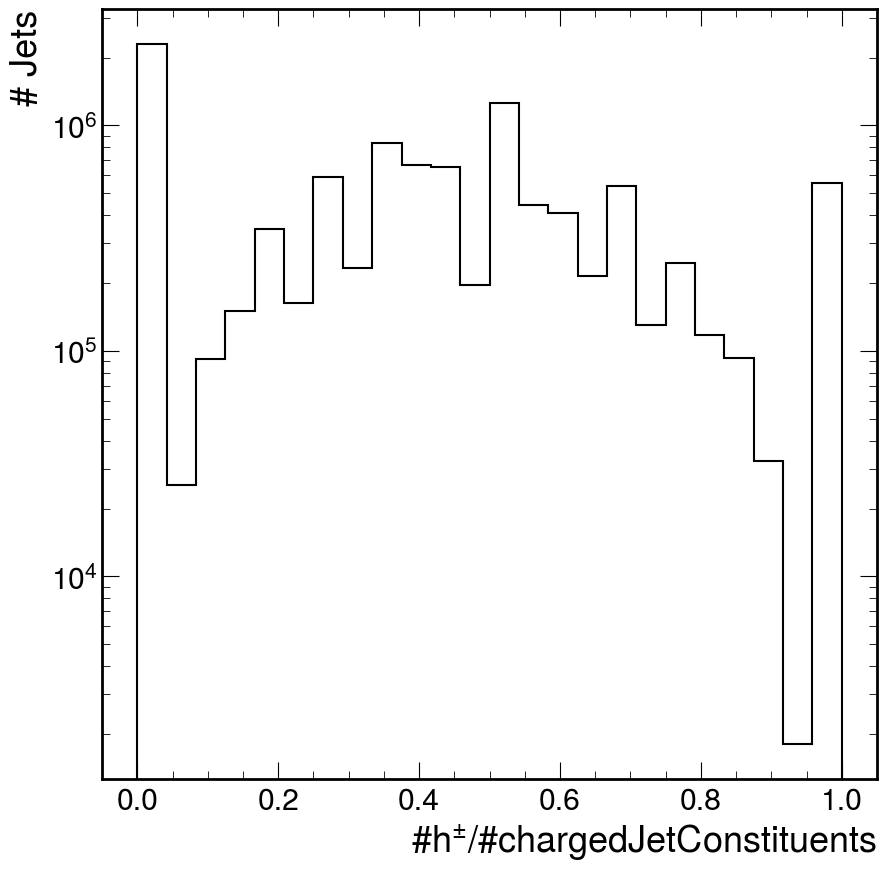

In [23]:
bins = np.linspace(0, 1, 25)

fig, ax, _ = plot_distribution(frac_chargedHadron_constituents, title="", xlabel=r"$ \# h^{\pm} / \# chargedJetConstituents $", ylabel="# Jets", xscale="linear", bins=bins)
output_path = os.path.join(OUTPUT_DIR, "frac_chargedHadron_constituents.png")
fig.savefig(output_path)

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


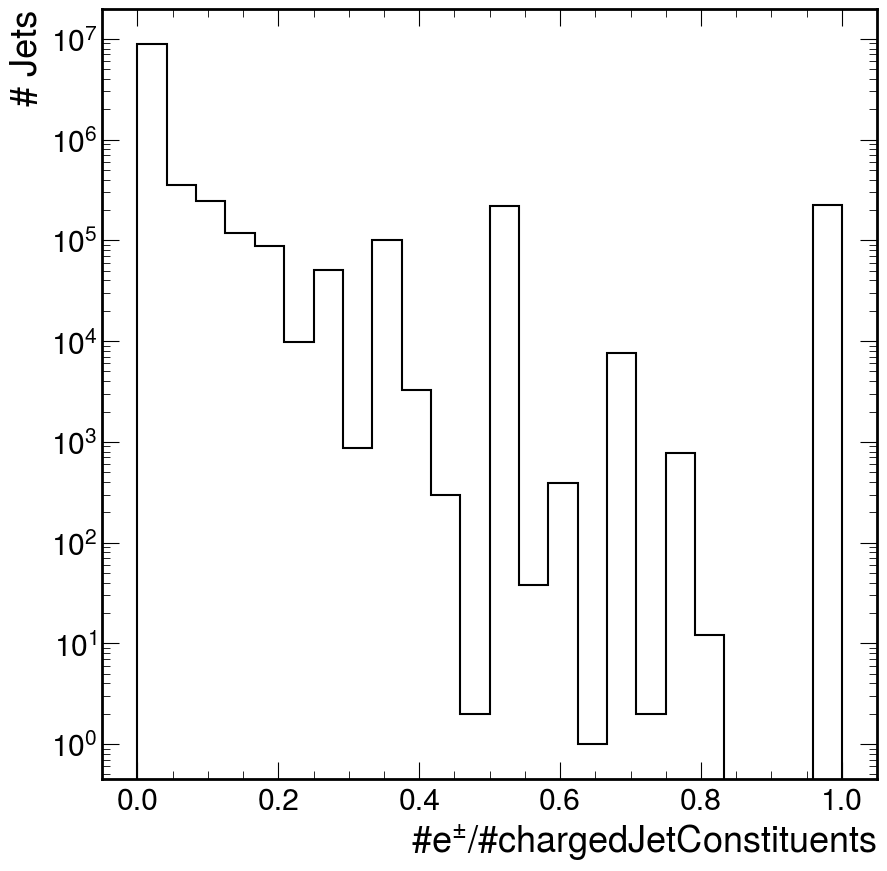

In [24]:
bins = np.linspace(0, 1, 25)
fig, ax, _ = plot_distribution(frac_electron_constituents, title="", xlabel=r"$\# e^{\pm} / \# chargedJetConstituents$", ylabel="# Jets", xscale="linear", bins=bins)
output_path = os.path.join(OUTPUT_DIR, "frac_electron_constituents.png")
fig.savefig(output_path)

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


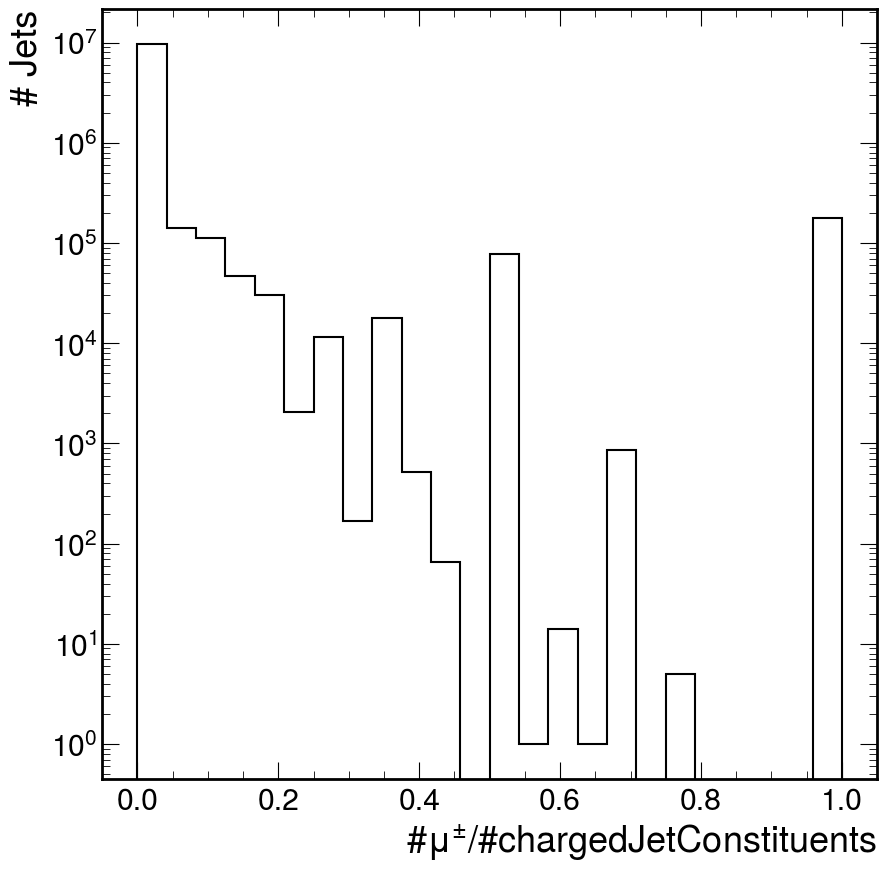

In [25]:
bins = np.linspace(0, 1, 25)
fig, ax, _ = plot_distribution(frac_muon_constituents, title="", xlabel=r"$ \#\mu^{\pm} / \# chargedJetConstituents$", ylabel="# Jets", xscale="linear", bins=bins)
output_path = os.path.join(OUTPUT_DIR, "frac_muon_constituents.png")
fig.savefig(output_path)

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


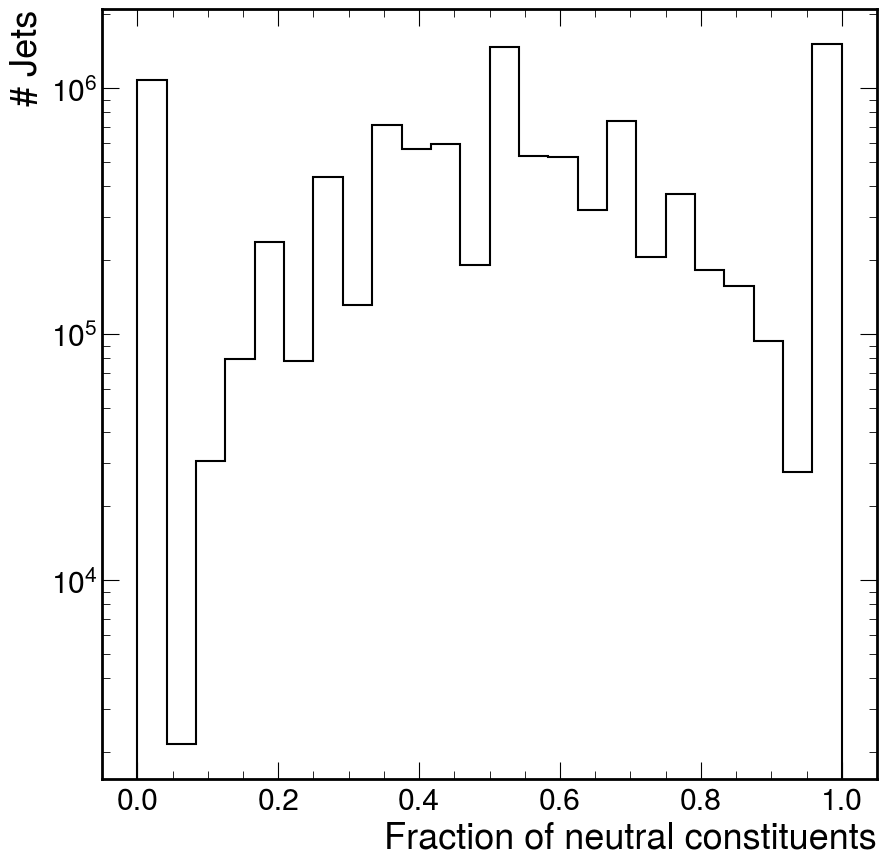

In [26]:
bins = np.linspace(0, 1, 25)
fig, ax, _ = plot_distribution(frac_neutral_constituents, title="", xlabel="Fraction of neutral constituents", ylabel="# Jets", xscale="linear", bins=bins)
output_path = os.path.join(OUTPUT_DIR, "frac_neutral_constituents.png")
fig.savefig(output_path)

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


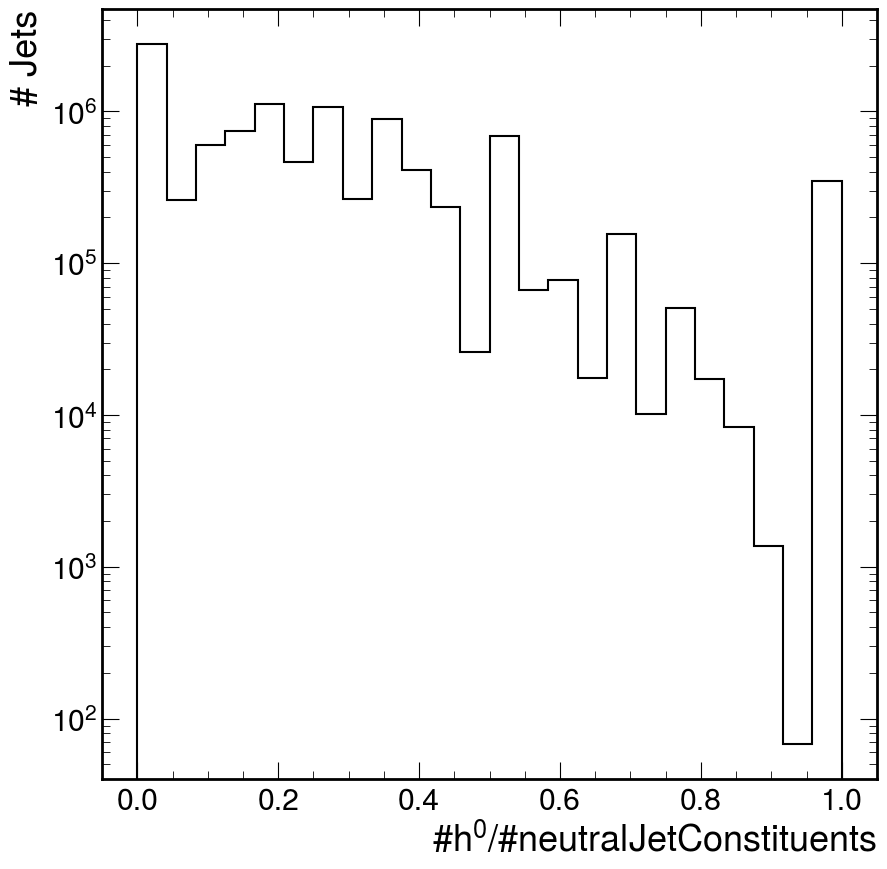

In [27]:
bins = np.linspace(0, 1, 25)
fig, ax, _ = plot_distribution(frac_neutralHadron_constituents, title="", xlabel=r"$ \# h^{0} / \# neutralJetConstituents$", ylabel="# Jets", xscale="linear", bins=bins)
output_path = os.path.join(OUTPUT_DIR, "frac_neutralHadron_constituents.png")
fig.savefig(output_path)

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


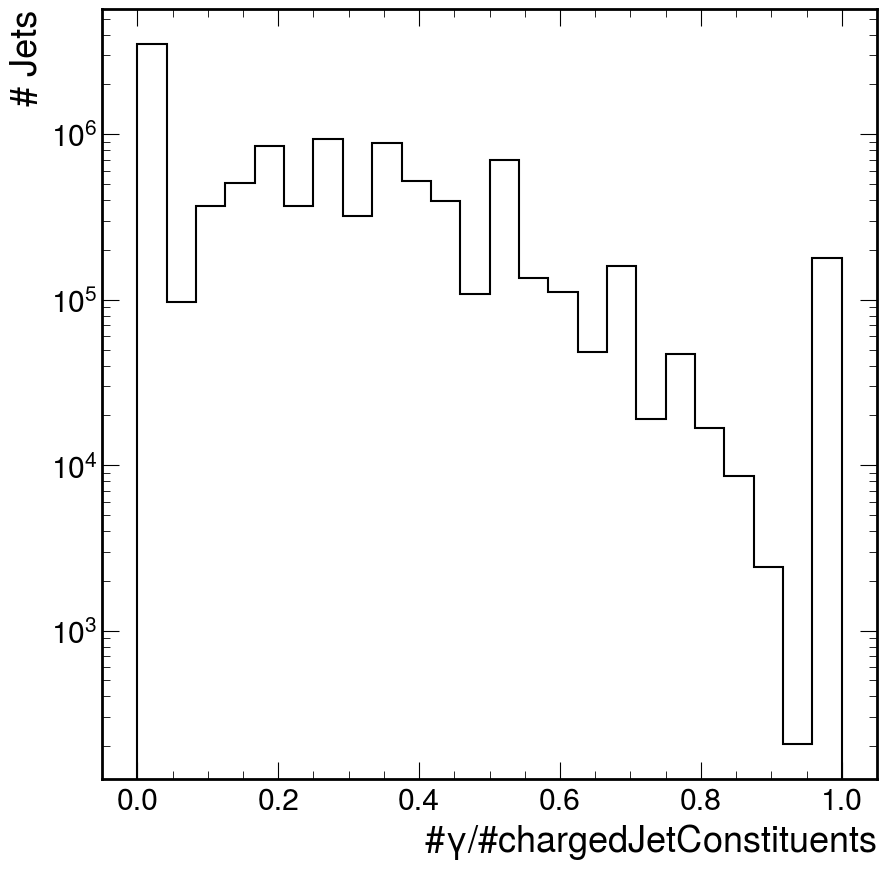

In [28]:
bins = np.linspace(0, 1, 25)
fig, ax, _ = plot_distribution(frac_photon_constituents, title="", xlabel=r"$ \# \gamma / \# chargedJetConstituents$", ylabel="# Jets", xscale="linear", bins=bins)
output_path = os.path.join(OUTPUT_DIR, "frac_photon_constituents.png")
fig.savefig(output_path)

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


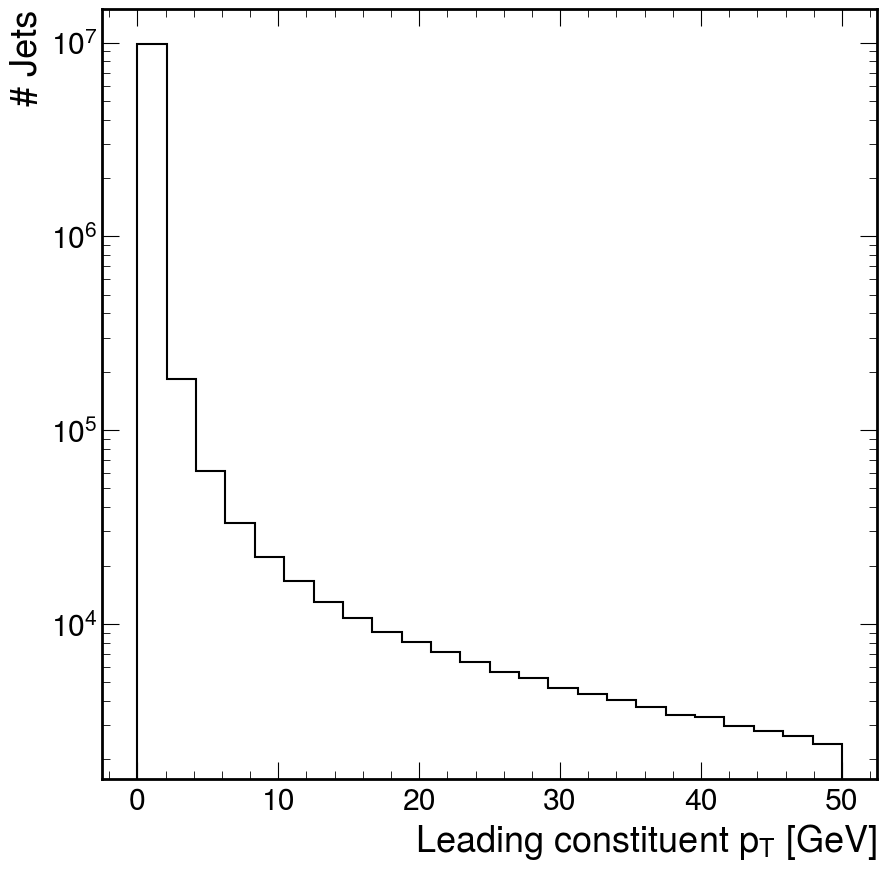

In [29]:
bins = np.linspace(0, 50, 25)
fig, ax, _ = plot_distribution(leading_particle_relpt, title="", xlabel=r"Leading constituent $p_T$ [GeV]", ylabel="# Jets", xscale="linear", bins=bins)
output_path = os.path.join(OUTPUT_DIR, "leading_particle_relpt.png")
fig.savefig(output_path)

# Validation plots

In [30]:
# Compare jet_eta and jet_eta_from cands etc.

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


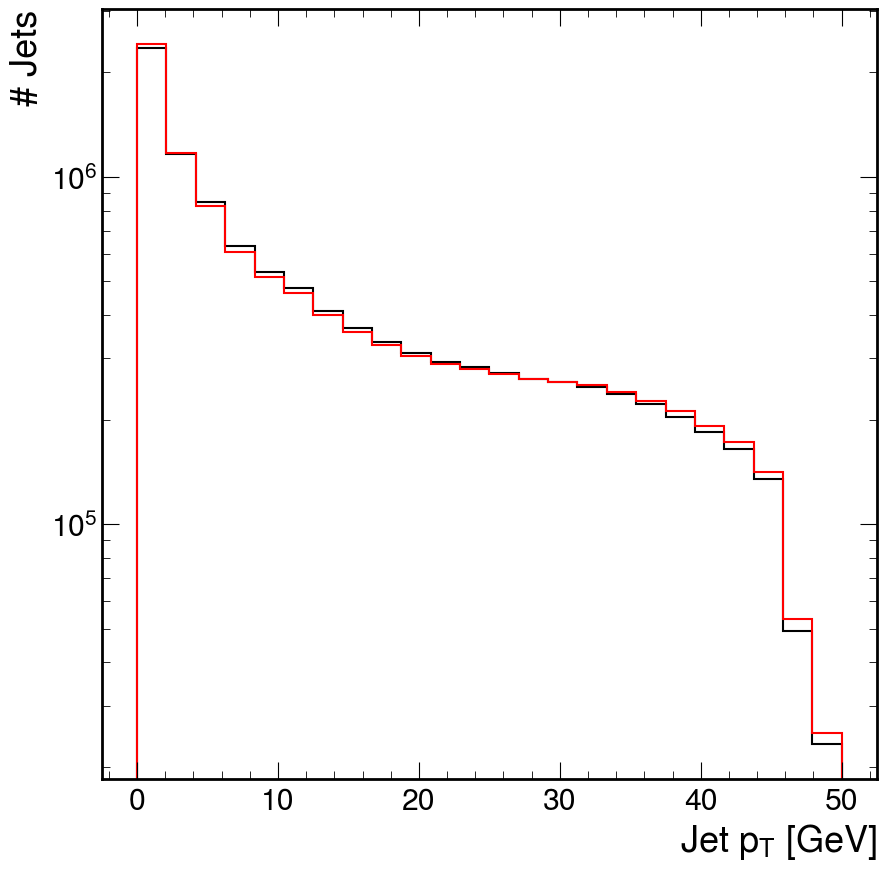

In [31]:
bins = np.linspace(0, 50, 25)
fig, ax, _ = plot_distribution(all_data.jet_pt, title="", xlabel=r"Jet $p_T$ [GeV]", ylabel="# Jets", xscale="linear", color="k", bins=bins)
fig, ax, _ = plot_distribution(all_data.jet_pt_from_p4s, title="", xlabel=r"Jet $p_T$ [GeV]", ylabel="# Jets", xscale="linear", color="r", bins=bins, fig=fig, ax=ax)
output_path = os.path.join(OUTPUT_DIR, "jet_pt_vs_jet_pt_from_const.png")
fig.savefig(output_path)

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


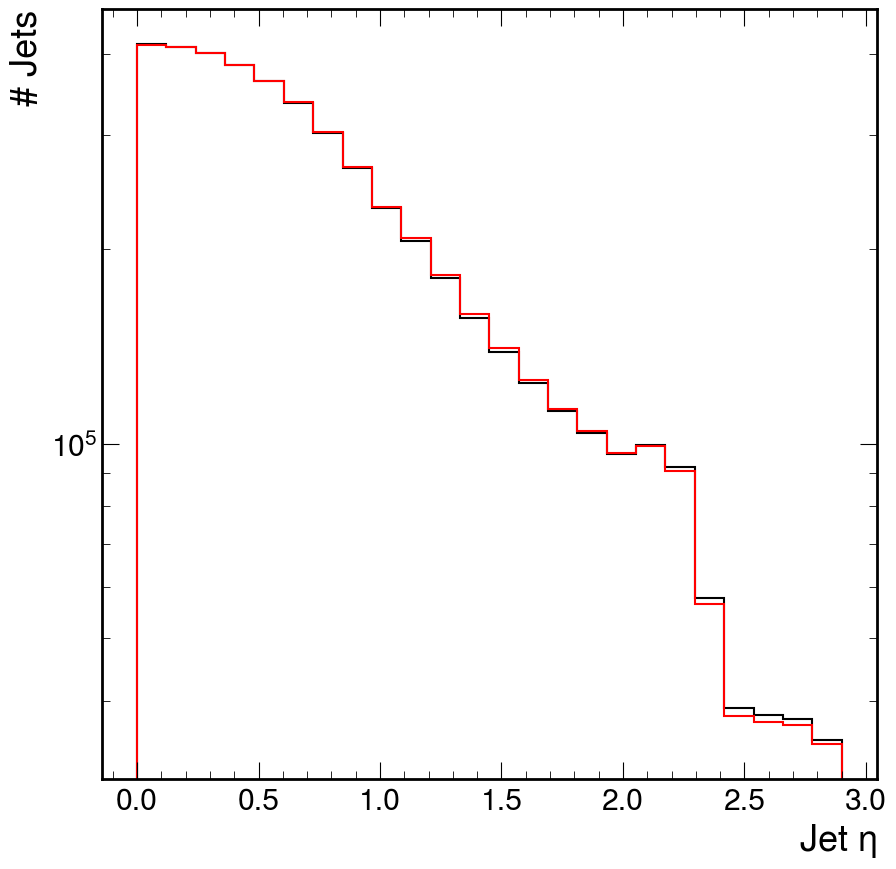

In [32]:
bins = np.linspace(0, 2.9, 25)
fig, ax, _ = plot_distribution(all_data.jet_eta, title="", xlabel=r"Jet $\eta$", ylabel="# Jets", xscale="linear", color="k", bins=bins)
fig, ax, _ = plot_distribution(all_data.jet_eta_from_p4s, title="", xlabel=r"Jet $\eta$", ylabel="# Jets", xscale="linear", color="r", bins=bins, fig=fig, ax=ax)
output_path = os.path.join(OUTPUT_DIR, "jet_eta_vs_jet_eta_from_const.png")
fig.savefig(output_path)

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


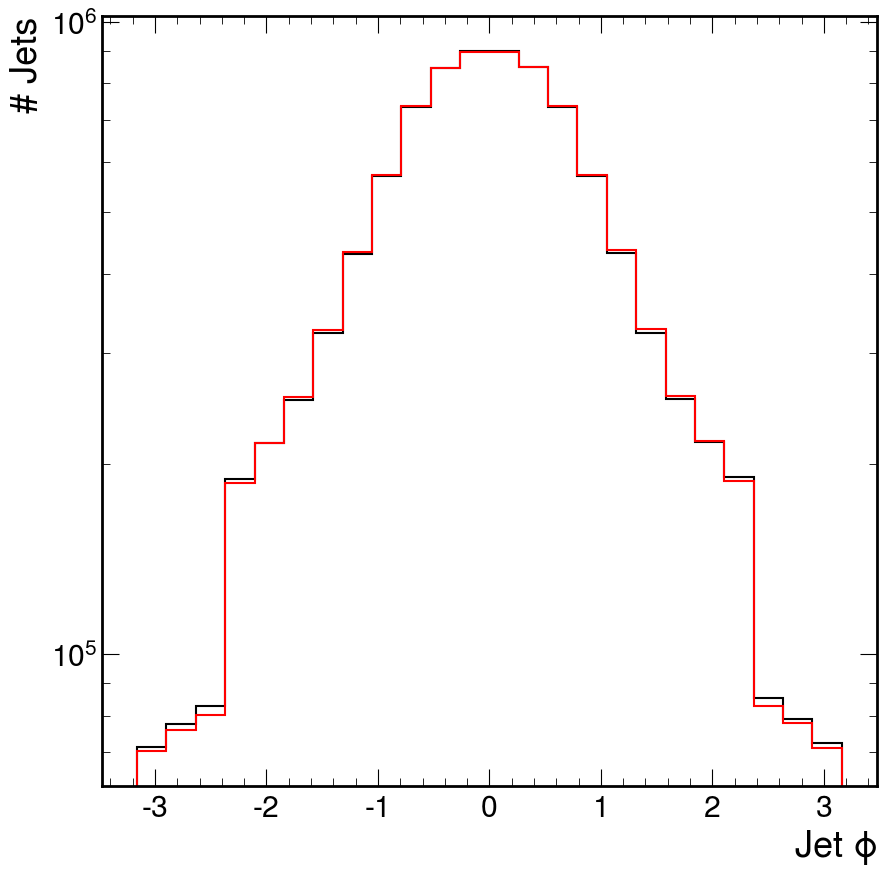

In [33]:
bins = np.linspace(-3.16, 3.16, 25)
fig, ax, _ = plot_distribution(all_data.jet_eta, title="", xlabel=r"Jet $\phi$", ylabel="# Jets", xscale="linear", color="k", bins=bins)
fig, ax, _ = plot_distribution(all_data.jet_eta_from_p4s, title="", xlabel=r"Jet $\phi$", ylabel="# Jets", xscale="linear", color="r", bins=bins, fig=fig, ax=ax)
output_path = os.path.join(OUTPUT_DIR, "jet_phi_vs_jet_phi_from_const.png")
fig.savefig(output_path)

# Lifetime variables

/tmp/ipykernel_1936222/109002521.py:1: RuntimeWarning: divide by zero encountered in log10
  bins = np.logspace(np.log10(0), np.log10(190), 25)
/opt/conda/lib/python3.11/site-packages/numpy/_core/function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
/opt/conda/lib/python3.11/site-packages/numpy/_core/function_base.py:172: RuntimeWarning: invalid value encountered in add
  y += start
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


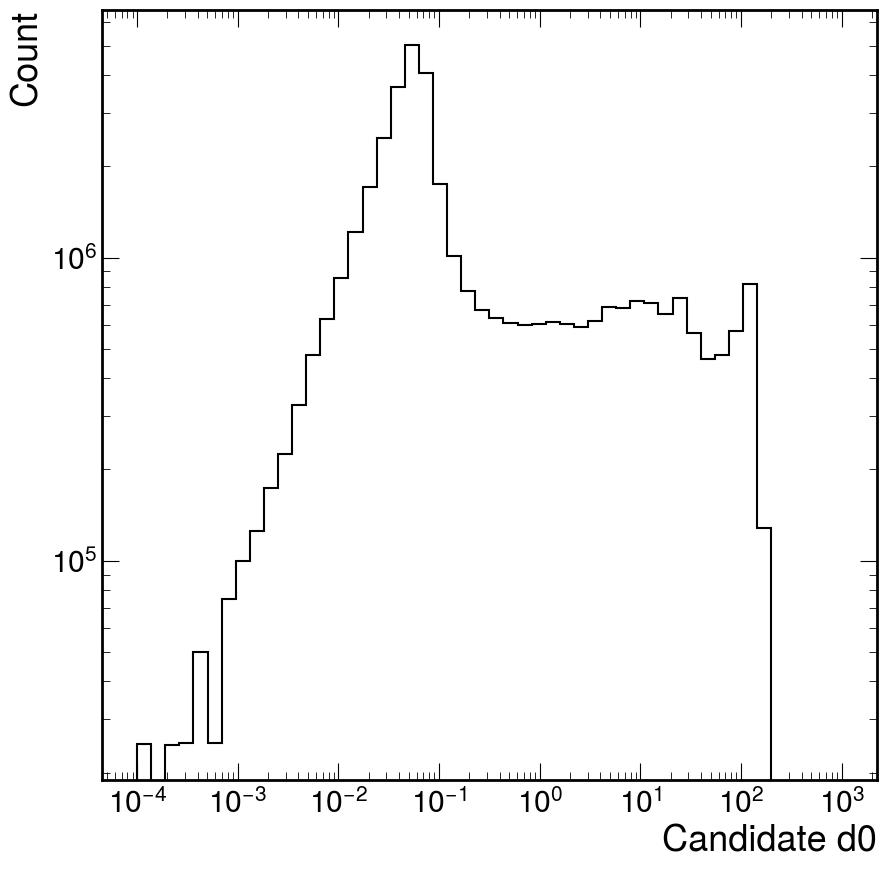

In [51]:
bins = np.logspace(np.log10(0), np.log10(190), 25)
fig, ax, _ = plot_distribution(abs(ak.flatten(all_data.part_d0val)), title="", xlabel=r"Candidate d0", ylabel="Count", xscale="log", color="k")
output_path = os.path.join(OUTPUT_DIR, "cand_d0.png")
fig.savefig(output_path)

/tmp/ipykernel_1936222/561985806.py:1: RuntimeWarning: divide by zero encountered in log10
  bins = np.logspace(np.log10(0), np.log10(7500), 25)
/opt/conda/lib/python3.11/site-packages/numpy/_core/function_base.py:162: RuntimeWarning: invalid value encountered in multiply
  y *= step
/opt/conda/lib/python3.11/site-packages/numpy/_core/function_base.py:172: RuntimeWarning: invalid value encountered in add
  y += start
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


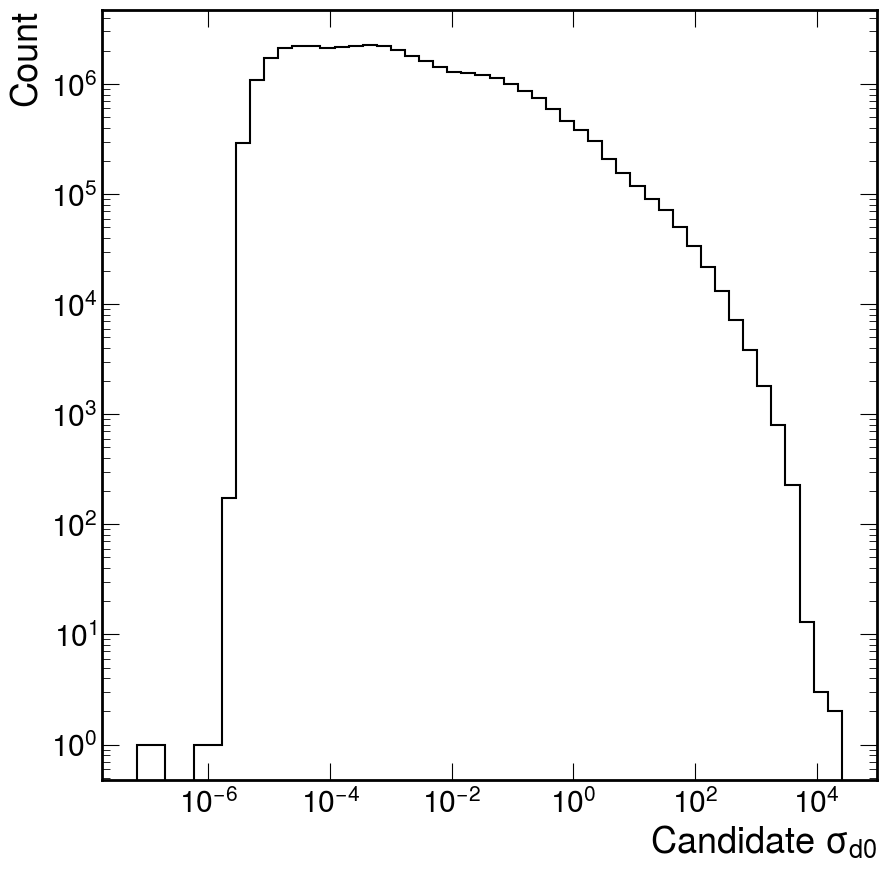

In [43]:
bins = np.logspace(np.log10(0), np.log10(7500), 25)
fig, ax, _ = plot_distribution(ak.flatten(all_data.part_d0err), title="", xlabel=r"Candidate $\sigma_{d0}$", ylabel="Count", xscale="log", color="k")
output_path = os.path.join(OUTPUT_DIR, "cand_d0err.png")
fig.savefig(output_path)

/tmp/ipykernel_1936222/4027651180.py:1: RuntimeWarning: divide by zero encountered in log10
  bins = np.logspace(np.log10(0), np.log10(1600), 25)
/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


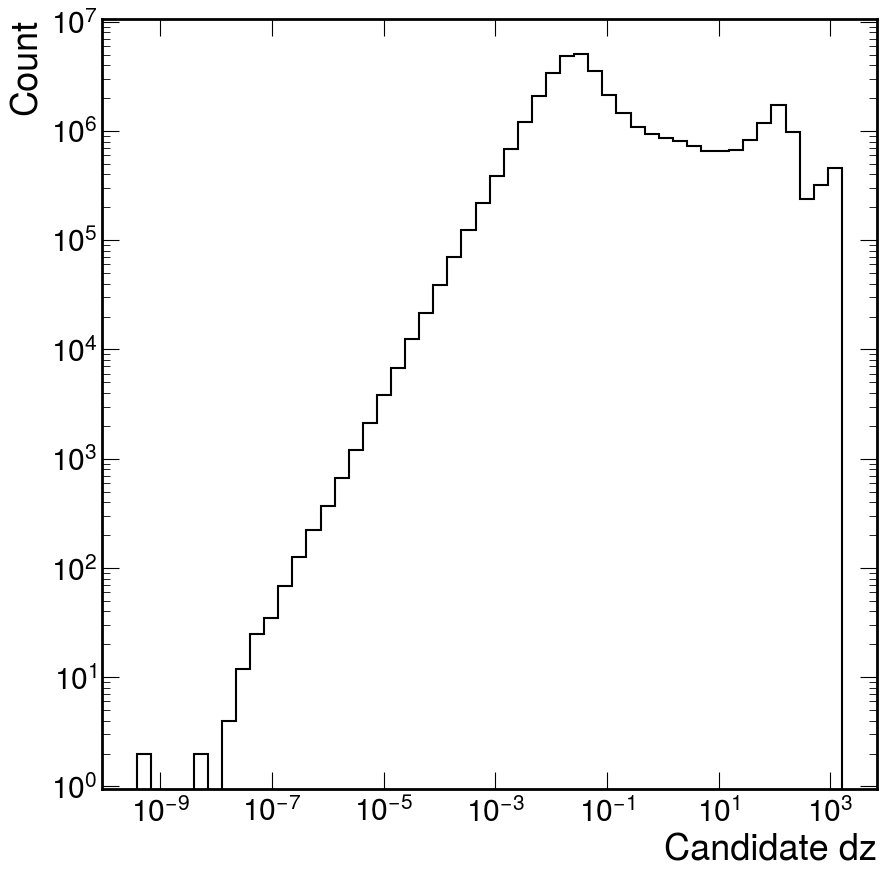

In [46]:
bins = np.logspace(np.log10(0), np.log10(1600), 25)
fig, ax, _ = plot_distribution(ak.flatten(all_data.part_dzval), title="", xlabel=r"Candidate dz", ylabel="Count", xscale="log", color="k")
output_path = os.path.join(OUTPUT_DIR, "cand_dz.png")
fig.savefig(output_path)

/tmp/ipykernel_1936222/665854207.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  data = np.array(data)


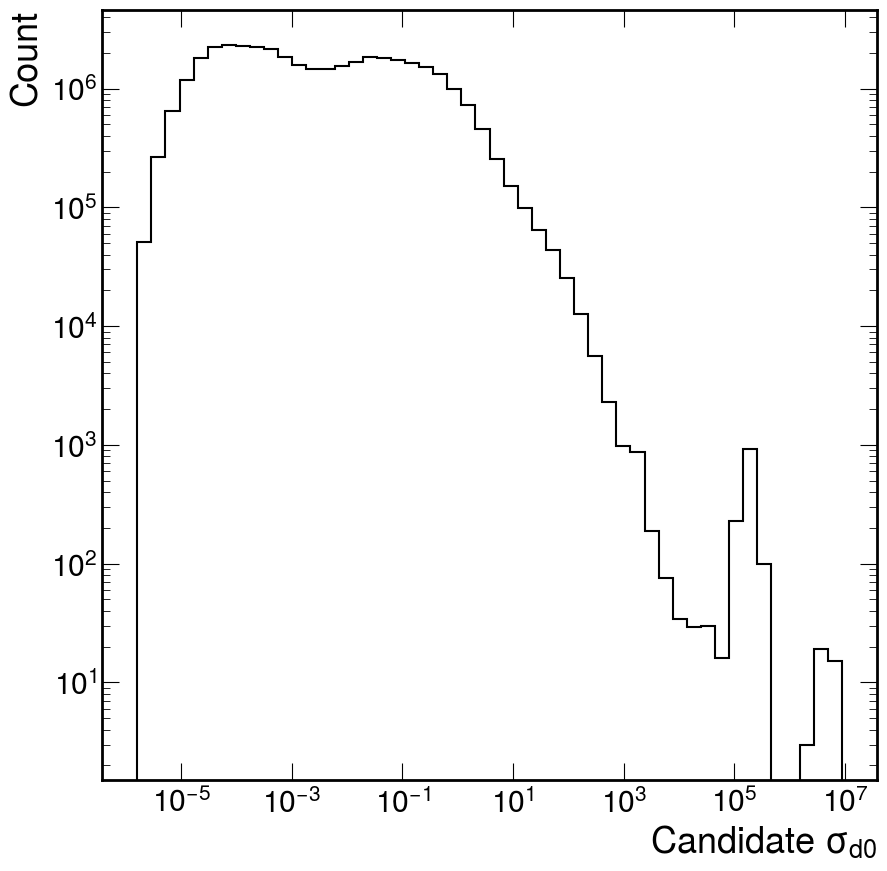

In [47]:
fig, ax, _ = plot_distribution(ak.flatten(all_data.part_dzerr), title="", xlabel=r"Candidate $\sigma_{d0}$", ylabel="Count", xscale="log", color="k")
output_path = os.path.join(OUTPUT_DIR, "cand_dzerr.png")
fig.savefig(output_path)